In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape[0])
print("Test images:", X_test.shape[0])
print("Image dimensions:", X_train.shape[1:])

Training images: 60000
Test images: 10000
Image dimensions: (28, 28)


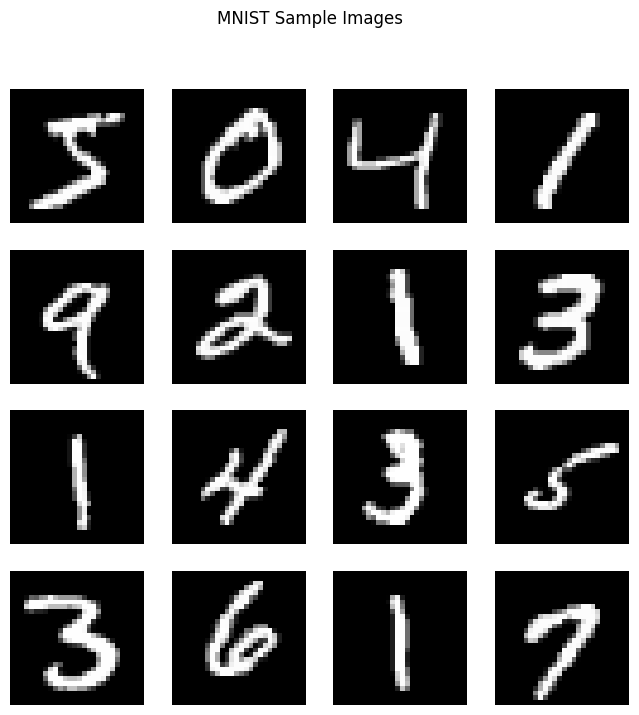

In [3]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis("off")

plt.suptitle("MNIST Sample Images")
plt.show()

In [4]:
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)

print("Reshaped dataset:", X_train.shape)

Reshaped dataset: (60000, 28, 28, 1)


In [6]:
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE, drop_remainder=True)

print("Batch size:", BATCH_SIZE)

Batch size: 128


In [7]:
LATENT_DIM = 100

generator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LATENT_DIM,)),
    tf.keras.layers.Dense(7 * 7 * 128, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 128)),

    tf.keras.layers.Conv2DTranspose(
        64, (5, 5), strides=(1, 1),
        padding="same", use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        32, (5, 5), strides=(2, 2),
        padding="same", use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        1, (5, 5), strides=(2, 2),
        padding="same", activation="tanh"
    )
])

generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,473 (3.47 MB)

 Trainable params: 896,737 (3.42 MB)

 Non-trainable params: 12,736 (49.75 KB)

In [8]:
noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(
    noise,
    training=False
)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


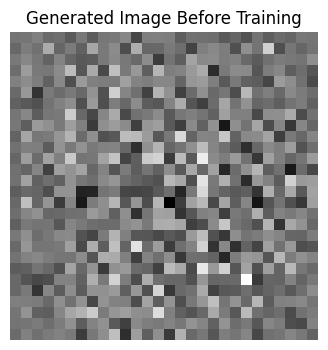

In [9]:
plt.figure(figsize=(4, 4))

plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)

plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()

In [10]:
discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        64, (5, 5),
        strides=(2, 2),
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128, (5, 5),
        strides=(2, 2),
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [12]:
generator.trainable = True
discriminator.trainable = True

noise_dim = 100
EPOCHS = 20

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

generator_losses = []
discriminator_losses = []

print(
    "Generator trainable variables:",
    len(generator.trainable_variables)
)

print(
    "Discriminator trainable variables:",
    len(discriminator.trainable_variables)
)

Generator trainable variables: 11
Discriminator trainable variables: 6


In [13]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, noise_dim]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [14]:
seed = tf.random.normal(
    [16, noise_dim]
)

def generate_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.show()

Epoch 1/20 | Generator Loss: 0.8530 | Discriminator Loss: 1.1616
Epoch 2/20 | Generator Loss: 0.8165 | Discriminator Loss: 1.2828
Epoch 3/20 | Generator Loss: 0.8259 | Discriminator Loss: 1.2791
Epoch 4/20 | Generator Loss: 0.8710 | Discriminator Loss: 1.2349
Epoch 5/20 | Generator Loss: 0.8903 | Discriminator Loss: 1.2383


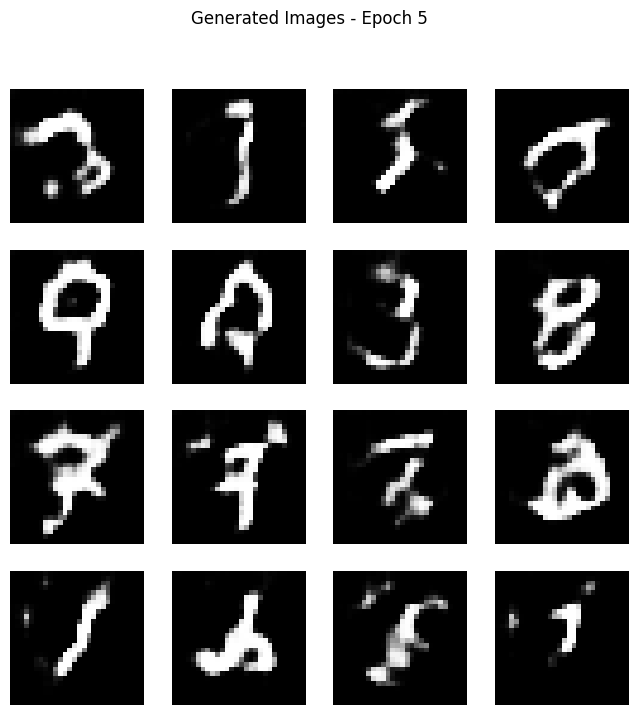

Epoch 6/20 | Generator Loss: 0.8498 | Discriminator Loss: 1.2721
Epoch 7/20 | Generator Loss: 0.8296 | Discriminator Loss: 1.2921
Epoch 8/20 | Generator Loss: 0.8257 | Discriminator Loss: 1.2946
Epoch 9/20 | Generator Loss: 0.8270 | Discriminator Loss: 1.2881
Epoch 10/20 | Generator Loss: 0.8263 | Discriminator Loss: 1.2876


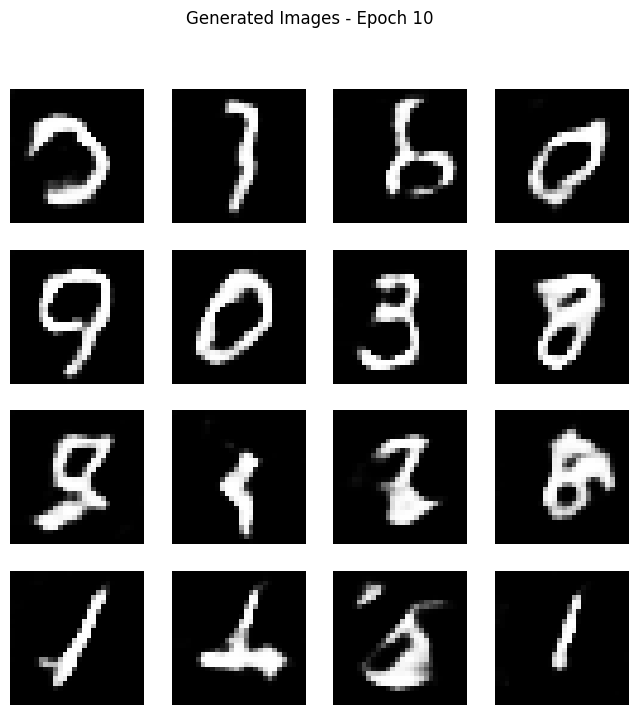

Epoch 11/20 | Generator Loss: 0.8288 | Discriminator Loss: 1.2879
Epoch 12/20 | Generator Loss: 0.8355 | Discriminator Loss: 1.2804
Epoch 13/20 | Generator Loss: 0.8457 | Discriminator Loss: 1.2773
Epoch 14/20 | Generator Loss: 0.8378 | Discriminator Loss: 1.2787
Epoch 15/20 | Generator Loss: 0.8392 | Discriminator Loss: 1.2790


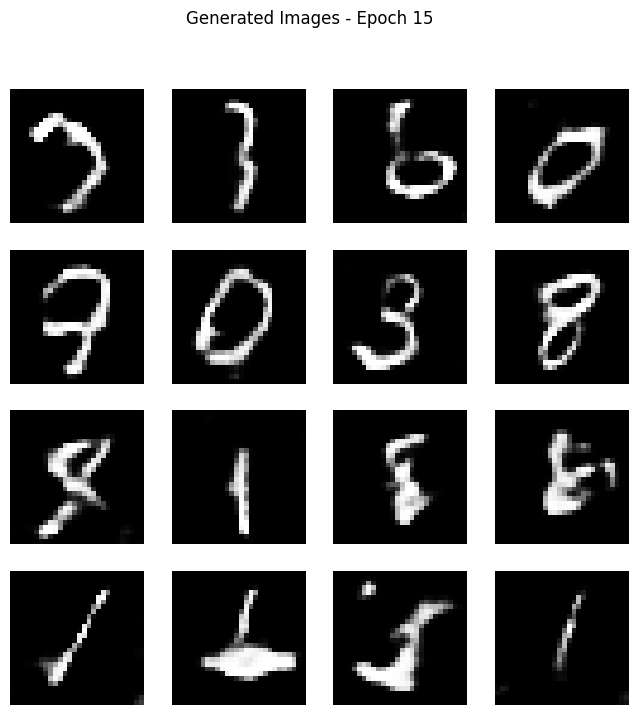

Epoch 16/20 | Generator Loss: 0.8622 | Discriminator Loss: 1.2683
Epoch 17/20 | Generator Loss: 0.8641 | Discriminator Loss: 1.2690
Epoch 18/20 | Generator Loss: 0.8565 | Discriminator Loss: 1.2691
Epoch 19/20 | Generator Loss: 0.8624 | Discriminator Loss: 1.2695
Epoch 20/20 | Generator Loss: 0.8575 | Discriminator Loss: 1.2726


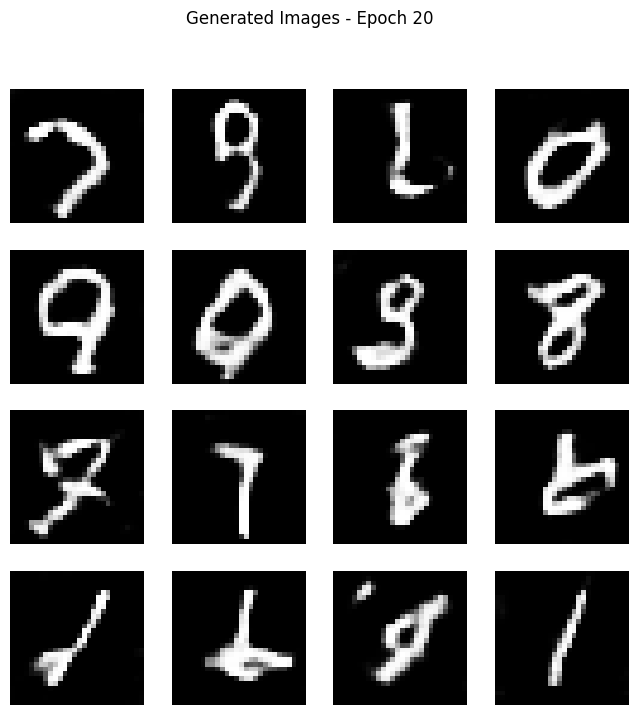

In [15]:
for epoch in range(EPOCHS):

    total_gen_loss = 0
    total_disc_loss = 0
    batches = 0

    for image_batch in dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        total_gen_loss += gen_loss
        total_disc_loss += disc_loss

        batches += 1

    avg_gen_loss = total_gen_loss / batches
    avg_disc_loss = total_disc_loss / batches

    generator_losses.append(
        float(avg_gen_loss)
    )

    discriminator_losses.append(
        float(avg_disc_loss)
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        generate_images(
            generator,
            epoch + 1,
            seed
        )

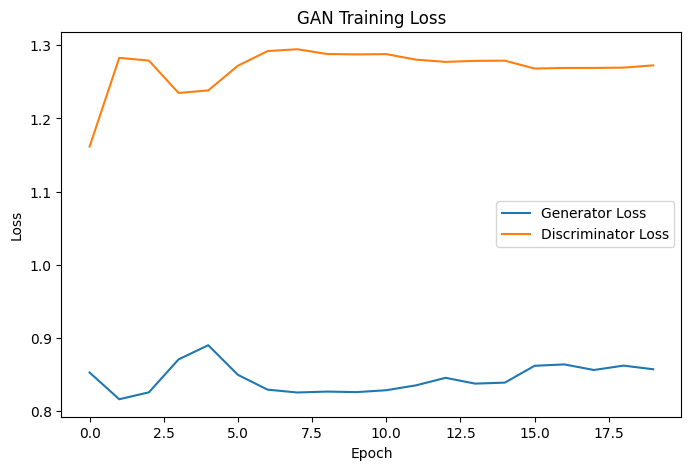

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()
plt.show()

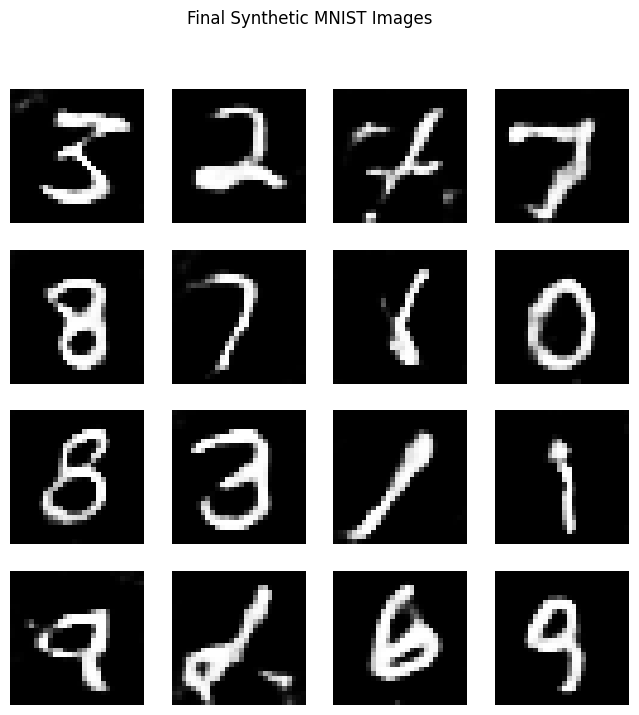

In [17]:
final_noise = tf.random.normal(
    [16, noise_dim]
)

final_images = generator(
    final_noise,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        final_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Synthetic MNIST Images"
)

plt.show()

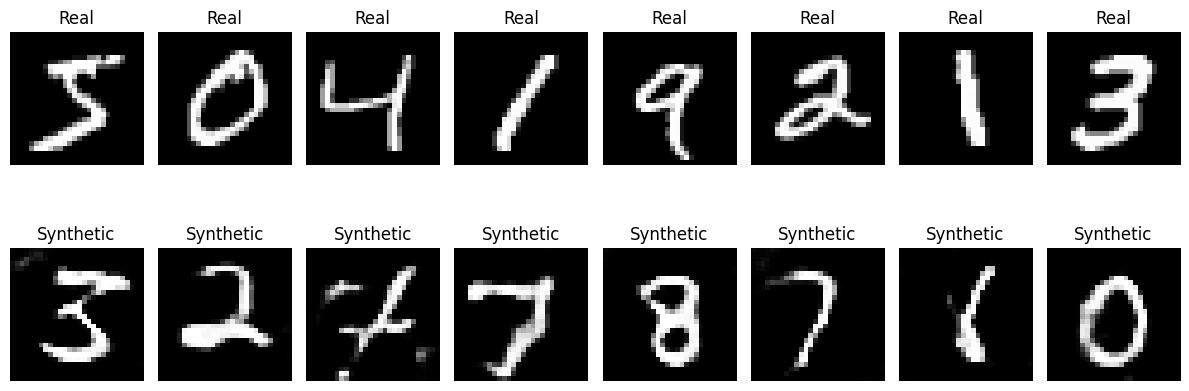

In [18]:
plt.figure(figsize=(12, 5))

for i in range(8):

    plt.subplot(2, 8, i + 1)

    plt.imshow(
        X_train[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.title("Real")
    plt.axis("off")

    plt.subplot(2, 8, i + 9)

    plt.imshow(
        final_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.title("Synthetic")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import os

print("OS module imported successfully.")

OS module imported successfully.


In [22]:
import os
import tensorflow as tf

os.makedirs("generated_images", exist_ok=True)

for i in range(16):
    image = final_images[i] * 127.5 + 127.5
    image = tf.cast(image, tf.uint8)

    tf.keras.utils.save_img(
        f"generated_images/generated_{i+1}.png",
        image,
        data_format="channels_last",
        scale=False
    )

print("Generated images saved successfully.")

Generated images saved successfully.


In [23]:
generator.save(
    "mnist_gan_generator.keras"
)

discriminator.save(
    "mnist_gan_discriminator.keras"
)

print("Generator and Discriminator models saved successfully.")

Generator and Discriminator models saved successfully.
